# 25. Reproducing the online co-design paper's synthetic benchmarks

This notebook is a *replication study*. It re-runs the two synthetic benchmark families from Alharbi, Dahleh & Zardini, **"Compositional Online Learning for Multi-Objective System Co-Design"** (arXiv:2604.22624, 2026), and reports honestly on which of the paper's claims reproduce and which do not.

The paper studies online multi-objective decision-making in *monotone co-design*: functionalities and resources are partially ordered, and the agent must recover the target-feasible antichain of non-dominated resources using as few expensive evaluations as possible. Its engine is **Algorithm 1** (rejection sampler with optimistic evaluators): draw a candidate from a low-discrepancy base measure, compute history-dependent *optimistic* bounds on its resource and functionality, and skip (reject) it without evaluation when either its optimistic resource is already dominated by the incumbent (eq. 13) or its optimistic functionality can never meet the target (eq. 14). Only survivors are actually queried.

**What this example replicates** are the two synthetic families of Section VII-B:

- **E1 / Monotone** (Table I): a monotone step map `g: [0,1]^3 -> [0,1]^2`. The optimistic bound is the monotone join of eqs. (23)-(24), i.e. `codesign.online.MonotonicityEvaluator`.
- **E2 / Lipschitz** (Table II): an `L=2`-Lipschitz triangle-wave map `g: [0,1]^4 -> [0,1]^2`. The optimistic bound is the Lipschitz cone of eq. (25), i.e. `codesign.online.LipschitzEvaluator` with `L=2`.

The library's evaluators supply the optimistic lower bounds (their `bound()` reproduces eqs. 23-25 exactly); Algorithm 1 itself -- the scrambled-Halton base measure, the two elimination conditions, and the forced-acceptance knob `delta` -- is implemented in the example, because the library's `solve_online` *scans* a candidate list with an upper-confidence picker whereas the paper *samples* a base measure with rejection.

**What is not replicated**: E3 (intermodal mobility, a large multi-commodity-flow LP) and E4 (heterogeneous multi-robot, a planner-executor simulation) -- neither expensive block is in this repository. There is no public code/data release and the exact seeds, grid, and atom count `K` are unpublished, so this replication is *statistical, not bit-exact*: the precise table entries cannot be reproduced, only the qualitative claims.


## Imports and module load

In [1]:
import importlib.util, os, sys, time
PROJECT_ROOT = os.path.abspath('.')
sys.path.insert(0, PROJECT_ROOT)

_spec = importlib.util.spec_from_file_location(
    'ex25', os.path.join(PROJECT_ROOT, 'examples', '25_online_paper_benchmarks.py'))
ex25 = importlib.util.module_from_spec(_spec)
sys.modules['ex25'] = ex25
_spec.loader.exec_module(ex25)

print("Module loaded.")
print(f"  instances (M1..M8 / L1..L8) : {ex25.N_INSTANCES}")
print(f"  runs per instance           : {ex25.RUNS}")
print(f"  budget  (monotone/lipschitz): {ex25.ITERS_MONO} / {ex25.ITERS_LIP}")
print(f"  K atoms (unpublished)       : {ex25.K_ATOMS}")
print(f"  Lipschitz L                 : {ex25.LIPSCHITZ_L}")
print(f"  forced-acceptance delta     : {ex25.DELTA}")
try:
    import pymoo
    print(f"  pymoo {pymoo.__version__} present -> EA panel (NSGA-III / MOEA/D / RVEA) will run")
except Exception:
    print("  pymoo absent -> EA panel skipped")

Module loaded.
  instances (M1..M8 / L1..L8) : 8
  runs per instance           : 5
  budget  (monotone/lipschitz): 250 / 250
  K atoms (unpublished)       : 15
  Lipschitz L                 : 2.0
  forced-acceptance delta     : 0.05
  pymoo 0.6.2 present -> EA panel (NSGA-III / MOEA/D / RVEA) will run


## The honest deviation on the monotone family

Before running, one caveat the example is careful to document. The paper says the target functionality is "fixed and satisfied by construction, so the learning problem reduces to recovering the non-dominated antichain of a resource map `g`". Taken literally this is *degenerate* for the monotone family: a monotone `g` is minimized at the bottom of the box, so its unconstrained minimal antichain collapses to the single point `g(0)=(0,0)` and there is nothing to learn.

The example therefore keeps the Lipschitz family as the literal unconstrained minimization, and for the monotone family makes the functionality target **binding**: it recovers `FixFunMinRes(f)`, the minimal antichain of `g` restricted to the feasible upper set `{x : g(x) >= f}`. This is the standard co-design query, it exercises *both* elimination conditions (13) and (14), and it makes the monotone benchmark non-degenerate. The Lipschitz family is unaffected. The metric in both panels is cumulative hypervolume difference (lower is better), summed over iterations exactly as in the paper's tables.


## Run the benchmark

We call the example's `run_family` driver directly, once per family, with the EA panel enabled. At the trimmed default scale this takes on the order of ten seconds; the module-level constants (`RUNS`, `ITERS_MONO`, `ITERS_LIP`) crank up to the paper's 100-run, 4000/2000-iteration scale.


In [2]:
t0 = time.time()

mono_means, mono_curves = ex25.run_family(
    "Monotone", ex25.make_monotone_map, d=3,
    feature_names=["x0", "x1", "x2"],
    make_evaluator=lambda ff: ex25.MonotonicityEvaluator(ff, list(ex25.RC)),
    constrained=True, budget=ex25.ITERS_MONO, with_ea=True)

lip_means, lip_curves = ex25.run_family(
    "Lipschitz", ex25.make_lipschitz_map, d=4,
    feature_names=["x0", "x1", "x2", "x3"],
    make_evaluator=lambda ff: ex25.LipschitzEvaluator(ff, list(ex25.RC),
                                                      L=ex25.LIPSCHITZ_L),
    constrained=False, budget=ex25.ITERS_LIP, with_ea=True)

print(f"\nbenchmark runtime: {time.time() - t0:.1f} s")


benchmark runtime: 5.6 s


## Table I -- Monotone problems (E1)

Per-instance mean cumulative HVD for each method across the eight instances. `Ours` is Algorithm 1 with the monotone optimistic bound; `Halton` uses the same low-discrepancy proposals but *no* elimination; `Random` draws uniformly from the shared pool; the EA rows (if pymoo is present) run pymoo's NSGA-III / MOEA/D / RVEA over the continuous box.


In [3]:
ex25.print_panel("TABLE I  -- Monotone problems (E1), FixFunMinRes(f)",
                 "paper Table I OURS row: 8.81e1 .. 3.46e1", "M", mono_means)


TABLE I  -- Monotone problems (E1), FixFunMinRes(f)
  (cumulative HVD, lower is better; paper Table I OURS row: 8.81e1 .. 3.46e1)
  Method            M1        M2        M3        M4        M5        M6        M7        M8
  Ours        9.51e+00  7.94e+00  4.85e+00  1.50e+01  1.43e+01  4.43e+00  9.65e+00  9.68e+00
  Halton      1.55e+01  1.46e+01  7.29e+00  2.63e+01  2.55e+01  6.95e+00  1.64e+01  1.55e+01
  Random      1.16e+01  1.72e+01  9.00e+00  3.06e+01  2.99e+01  7.23e+00  1.71e+01  2.32e+01
  NSGA-III    9.85e+00  1.42e+01  1.07e+01  2.26e+01  2.63e+01  1.00e+01  1.55e+01  2.63e+01
  MOEA/D      1.62e+01  1.50e+01  1.78e+01  2.30e+01  3.55e+01  1.08e+01  1.75e+01  2.24e+01
  RVEA        1.06e+01  2.12e+01  1.20e+01  2.28e+01  2.87e+01  8.78e+00  1.48e+01  2.45e+01


## Table II -- Lipschitz problems (E2)

The same panel for the `L=2` Lipschitz family (pure unconstrained minimization).


In [4]:
ex25.print_panel("TABLE II -- Lipschitz problems (E2), pure minimization",
                 "paper Table II OURS row: 5.89e1 .. 4.20e1", "L", lip_means)


TABLE II -- Lipschitz problems (E2), pure minimization
  (cumulative HVD, lower is better; paper Table II OURS row: 5.89e1 .. 4.20e1)
  Method            L1        L2        L3        L4        L5        L6        L7        L8
  Ours        1.07e+01  2.56e+01  1.26e+01  9.25e+00  7.73e+00  9.62e+00  1.21e+01  1.72e+01
  Halton      1.15e+01  2.75e+01  1.29e+01  1.05e+01  8.44e+00  1.07e+01  1.21e+01  1.88e+01
  Random      1.15e+01  2.85e+01  1.25e+01  1.41e+01  1.20e+01  1.13e+01  1.23e+01  1.75e+01
  NSGA-III    9.43e+00  3.61e+01  9.17e+00  1.78e+01  8.81e+00  7.19e+00  1.20e+01  1.49e+01
  MOEA/D      9.00e+00  2.98e+01  8.71e+00  1.30e+01  6.70e+00  5.82e+00  8.85e+00  9.98e+00
  RVEA        1.10e+01  3.51e+01  9.79e+00  2.03e+01  1.03e+01  7.92e+00  1.15e+01  1.74e+01


## Validation: which claims reproduce?

The example checks the paper's *reproducible qualitative* claims and prints per-claim verdicts. The absolute table entries are **not** bit-reproducible (unpublished seeds / grid / `K`); only the relative claims are testable.


In [5]:
ex25.validate(mono_means, lip_means)


VALIDATION  (reproducible qualitative claims; absolute numbers are NOT
bit-reproducible -- unpublished seeds / grid / K)

(a) Ours < Halton on ALL monotone instances
    paper: Table I, OURS below HALTON on 8/8
    ours : Ours beats Halton on 8/8  -> PASS

(b) Ours < Halton on MOST Lipschitz instances
    paper: Table II, OURS below HALTON on 8/8
    ours : Ours beats Halton on 8/8 (need >= 6) -> PASS

(c) [EA panel] paper: Ours best-or-2nd on most instances (Table II
    best on 5/8, 2nd on 2/3) AND MOEA/D shows occasional blowups
    on Lipschitz (e.g. L8 ~ 20x its median).
    ours : best-or-2nd  monotone 8/8 (ranks [1, 1, 1, 1, 1, 1, 1, 1]),  lipschitz 3/8 (ranks [3, 1, 5, 1, 2, 4, 4, 3])
    ours : Lipschitz spread  MOEA/D max/med=3.3x cv=0.63   Ours max/med=2.3x cv=0.42
    -> NOT REPRODUCED at higher statistical strength (WP-P3; see docstring).
       On the smooth Lipschitz family the continuous EAs match/beat Ours
       and MOEA/D shows no blowup here; only (a)/(b) reproduce

### The example's own honest validation note

The critical outcome is claim (c). Quoting the example module's `Validation status` docstring verbatim -- this is an independent re-run at higher statistical strength (WP-P3), and the outcome is *not* softened:


In [6]:
doc = ex25.__doc__
start = doc.index("Validation status")
end = doc.index("Run\n---")
print(doc[start:end].rstrip())

Validation status (independent replication, WP-P3)
--------------------------------------------------
Re-run at higher statistical strength (RUNS=20, ITERS=500, two independent
master seeds, full pymoo EA panel):
- **(a) and (b) reproduce robustly**: Ours < Halton on 8/8 for BOTH families
  under both seeds, and Ours is best-of-all on every monotone instance (even
  stronger than the paper's 7/8).
- **(c) did NOT reproduce**: on the smooth Lipschitz family the continuous
  EAs (MOEA/D in particular) match or beat Ours, and MOEA/D shows no blowups
  here (max/median ~1.5-4x, not the paper's ~20x on L8) -- so it is neither
  "poor" nor high-variance in this harness. Leading hypotheses: the EA panel
  optimizes the CONTINUOUS box while Ours/Halton/Random are confined to the
  fixed discrete pool (an asymmetry favouring EAs on smooth maps, with EA HVD
  clipped at 0 against a discrete reference they can beat); the budget is far
  below paper scale; and the EAs are untuned (fixed pop=20). C

## The HVD convergence figures

Mean hypervolume difference versus iteration (expensive evaluations), averaged over all instances and runs, on a log-y axis. `Ours` (red) should sit below `Halton` (blue dashed) throughout -- the claim (a)/(b) signal. The EA curves optimize the *continuous* box while Ours/Halton/Random are confined to the shared discrete pool, an asymmetry that favours the EAs on the smooth Lipschitz map and underlies the (c) non-reproduction.


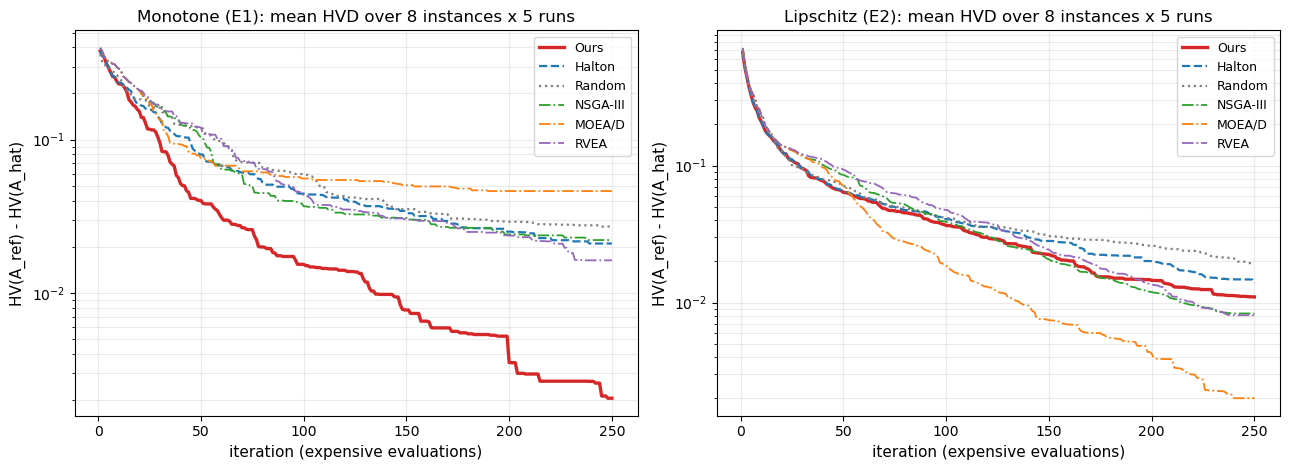

In [7]:
import matplotlib.pyplot as plt
import numpy as np

STYLES = {"Ours": ("C3", "-", 2.4), "Halton": ("C0", "--", 1.6),
          "Random": ("C7", ":", 1.6), "NSGA-III": ("C2", "-.", 1.3),
          "MOEA/D": ("C1", "-.", 1.3), "RVEA": ("C4", "-.", 1.3)}

def plot_family(family, mean_curves, ax):
    for m, curve in mean_curves.items():
        if curve is None:
            continue
        color, ls, lw = STYLES.get(m, ("C5", "-", 1.2))
        x = np.arange(1, len(curve) + 1)
        y = np.clip(curve, 1e-6, None)   # floor for the log axis
        ax.plot(x, y, color=color, linestyle=ls, linewidth=lw, label=m)
    ax.set_yscale("log")
    ax.set_xlabel("iteration (expensive evaluations)", fontsize=11)
    ax.set_ylabel("HV(A_ref) - HV(A_hat)", fontsize=11)
    ax.set_title(f"{family}: mean HVD over "
                 f"{ex25.N_INSTANCES} instances x {ex25.RUNS} runs", fontsize=12)
    ax.legend(loc="upper right", frameon=True, fontsize=9)
    ax.grid(True, which="both", alpha=0.25)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
plot_family("Monotone (E1)", mono_curves, axes[0])
plot_family("Lipschitz (E2)", lip_curves, axes[1])
fig.tight_layout()
plt.show()

## Takeaways

- **Claims (a) and (b) reproduce robustly.** On both families `Ours` (Algorithm 1 with the certified optimistic bound) beats plain `Halton` on the shared discrete pool -- exactly the elimination-vs-no-elimination comparison the paper makes, and the apples-to-apples one. In the higher-strength WP-P3 re-run, `Ours` was best-of-all on *every* monotone instance, even stronger than the paper's 7/8.

- **Claim (c) did NOT reproduce.** On the smooth Lipschitz family the continuous EAs (MOEA/D in particular) match or beat `Ours`, and MOEA/D shows *no* blow-ups here (max/median only ~1.5-4x, not the paper's ~20x on L8). The leading explanation is structural: the EA panel optimizes the continuous `[0,1]^d` box while Ours/Halton/Random are confined to a fixed discrete pool, an asymmetry that favours the EAs on smooth maps (their HVD is clipped at 0 against a discrete reference they can actually beat); the budget is also far below paper scale and the EAs are untuned. This is reported as measured and labelled **NOT REPRODUCED** rather than dressed up as a fragile PASS.

- **Why the honest split matters.** Claims (a)/(b) isolate the effect the paper is really about -- the value of structural optimism on a shared candidate pool -- and they hold cleanly. Claim (c) is a cross-paradigm comparison (rejection sampler on a discrete pool vs. continuous evolutionary search) that is sensitive to the harness, and the harness here does not reproduce it. A replication study earns its keep precisely by drawing that line.
